# Recommendation System

In [180]:
# Core data processing
import pandas as pd
import re

# Database
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

# Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine Learning - Core
from catboost import CatBoostClassifier, Pool

# Machine Learning scikit - components
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import roc_auc_score

# Deep Learning components
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DataCollatorWithPadding
from transformers import DataCollatorWithPadding, DistilBertModel, RobertaModel, BertModel, AutoTokenizer

# Visualization
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

import gc

In [94]:
"""
DATA LOADING FROM DATABASE

 Purpose: Load and combine user, post, and interaction data from PostgreSQL

  users: User demographic information
  posts_text: Post`s content 
  uniq_act: Reactions of all unique users
  acts: Action batch
"""
load_dotenv(dotenv_path='.env', override=True)

def get_engine():
    user = os.getenv("POSTGRES_USER")
    password = os.getenv("POSTGRES_PASSWORD")
    host = os.getenv("POSTGRES_HOST")
    port = os.getenv("POSTGRES_PORT")
    db = os.getenv("POSTGRES_DATABASE")
    
    url = f"postgresql://{user}:{password}@{host}:{port}/{db}"
    
    return create_engine(url)
    


if __name__ == "__main__":
    engine = get_engine()

    users = pd.read_sql("SELECT * FROM public.user_data", con=engine)
    post_text = pd.read_sql("SELECT * FROM public.post_text_df", con=engine)
    uniq_act = pd.read_sql("SELECT DISTINCT ON (user_id, target, action) user_id, post_id, timestamp, target FROM public.feed_data WHERE action='view'", con=engine)
    acts = pd.read_sql("SELECT user_id, post_id, timestamp, target FROM public.feed_data WHERE action='view' ORDER BY random() LIMIT 3000000", con=engine)

# Combine interaction data: unique actions + sampled interactions
all_actions = pd.concat([uniq_act, acts], axis=0)
df = pd.merge(users, all_actions, on='user_id',how='left')

In [95]:
all_actions

,user_id,post_id,timestamp,target
0,200,1773,2021-12-29 15:24:59,0
1,200,6264,2021-10-02 14:07:30,1
2,201,5640,2021-12-03 11:18:19,0
3,201,5524,2021-11-30 15:27:16,1
4,202,3475,2021-12-28 16:55:35,0
...,...,...,...,...
2999995,80978,1019,2021-11-04 08:59:16,0
2999996,54111,1908,2021-12-28 08:56:17,0
2999997,109809,2474,2021-12-16 13:32:10,0
2999998,2453,870,2021-12-02 21:00:57,0


## EDA

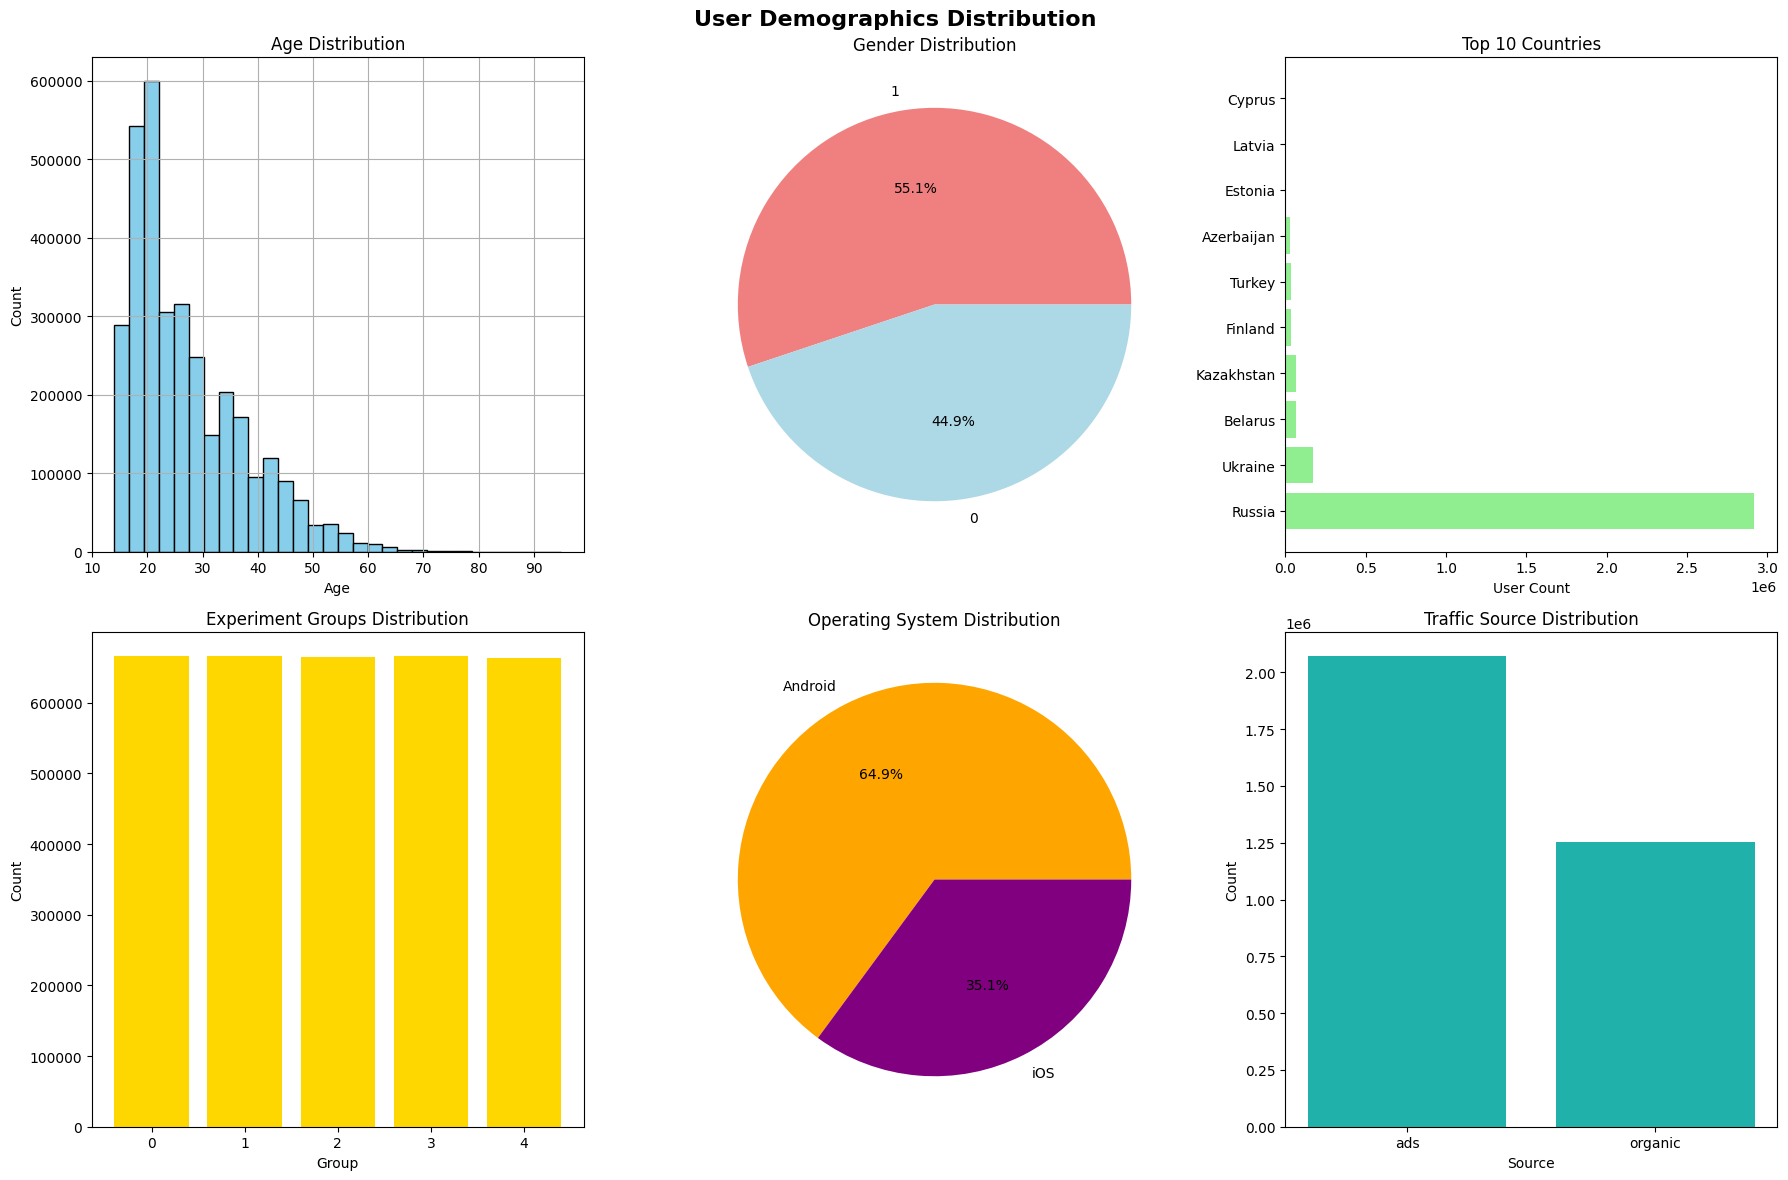

Age statistics:
Mean: 27.2, Median: 24.0
Min: 14, Max: 95
Gender ratio: {1: 1834045, 0: 1492362}


In [96]:
# User demographics analysis

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('User Demographics Distribution', fontsize=16, fontweight='bold')

# Age distribution
df['age'].hist(bins=30, ax=axes[0,0], color='skyblue', edgecolor='black')
axes[0,0].set_title('Age Distribution')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Count')

# Gender distribution
gender_counts = df['gender'].value_counts()
axes[0,1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue'])
axes[0,1].set_title('Gender Distribution')

# Country distribution
country_top10 = df['country'].value_counts().head(10)
axes[0,2].barh(range(len(country_top10)), country_top10.values, color='lightgreen')
axes[0,2].set_yticks(range(len(country_top10)))
axes[0,2].set_yticklabels(country_top10.index)
axes[0,2].set_title('Top 10 Countries')
axes[0,2].set_xlabel('User Count')

# Experiment groups
exp_counts = df['exp_group'].value_counts()
axes[1,0].bar(exp_counts.index, exp_counts.values, color='gold')
axes[1,0].set_title('Experiment Groups Distribution')
axes[1,0].set_xlabel('Group')
axes[1,0].set_ylabel('Count')

# OS distribution
os_counts = df['os'].value_counts()
axes[1,1].pie(os_counts.values, labels=os_counts.index, autopct='%1.1f%%', colors=['orange', 'purple'])
axes[1,1].set_title('Operating System Distribution')

# Traffic source
source_counts = df['source'].value_counts()
axes[1,2].bar(source_counts.index, source_counts.values, color='lightseagreen')
axes[1,2].set_title('Traffic Source Distribution')
axes[1,2].set_xlabel('Source')
axes[1,2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Demographic statistics
print(f"Age statistics:")
print(f"Mean: {df['age'].mean():.1f}, Median: {df['age'].median():.1f}")
print(f"Min: {df['age'].min()}, Max: {df['age'].max()}")
print(f"Gender ratio: {gender_counts.to_dict()}")


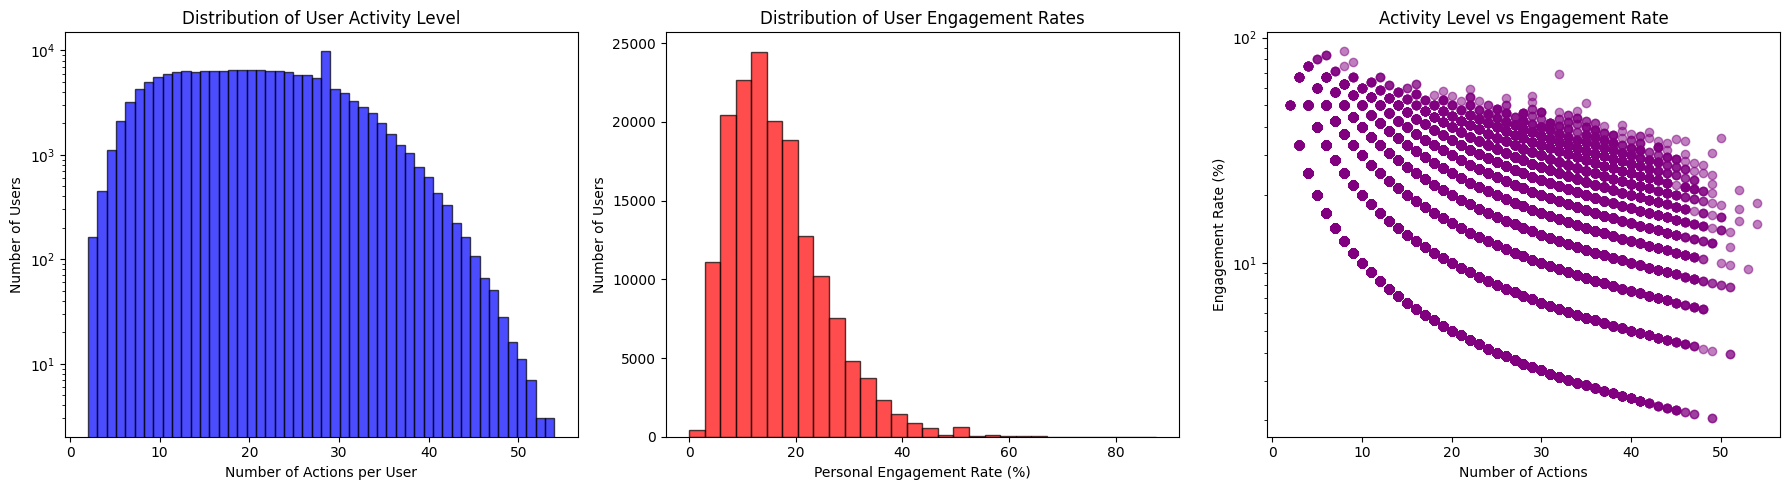

User Behavior Statistics:
Average actions per user: 20.4
Median actions per user: 20.0
Most active user: 54 actions
Average personal engagement rate: 16.57%
Correlation (activity vs engagement): -0.246


In [97]:
# User behavior analysis
fig.suptitle('Content and Engagement Analysis', fontsize=16, fontweight='bold')

# User activity levels
user_activity = df.groupby('user_id').size()
user_engagement = df.groupby('user_id')['target'].mean()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# User activity distribution
axes[0].hist(user_activity, bins=50, color='blue', alpha=0.7, edgecolor='black')
axes[0].set_title('Distribution of User Activity Level')
axes[0].set_xlabel('Number of Actions per User')
axes[0].set_ylabel('Number of Users')
axes[0].set_yscale('log')

# User engagement distribution
axes[1].hist(user_engagement * 100, bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of User Engagement Rates')
axes[1].set_xlabel('Personal Engagement Rate (%)')
axes[1].set_ylabel('Number of Users')

# Activity vs Engagement scatter
axes[2].scatter(user_activity, user_engagement * 100, alpha=0.5, color='purple')
axes[2].set_title('Activity Level vs Engagement Rate')
axes[2].set_xlabel('Number of Actions')
axes[2].set_ylabel('Engagement Rate (%)')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

print("User Behavior Statistics:")
print(f"Average actions per user: {user_activity.mean():.1f}")
print(f"Median actions per user: {user_activity.median():.1f}")
print(f"Most active user: {user_activity.max()} actions")
print(f"Average personal engagement rate: {user_engagement.mean() * 100:.2f}%")
print(f"Correlation (activity vs engagement): {user_activity.corr(user_engagement):.3f}")

In [98]:
# Display information about the DataFrames
print("Data Info:")
df.info()

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 3326407 entries, 0 to 3326406
Data columns (total 11 columns):
 #   Column     Dtype         
---  ------     -----         
 0   user_id    int64         
 1   gender     int64         
 2   age        int64         
 3   country    str           
 4   city       str           
 5   exp_group  int64         
 6   os         str           
 7   source     str           
 8   post_id    int64         
 9   timestamp  datetime64[us]
 10  target     int64         
dtypes: datetime64[us](1), int64(6), str(4)
memory usage: 279.2 MB


In [99]:
df.describe()

,user_id,gender,age,exp_group,post_id,timestamp,target
count,3.326407e+06,3.326407e+06,3.326407e+06,3.326407e+06,3.326407e+06,3326407,3.326407e+06
mean,8.506236e+04,5.513592e-01,2.719660e+01,1.997717e+00,3.396309e+03,2021-11-15 04:19:43.267465,1.566146e-01
min,2.000000e+02,0.000000e+00,1.400000e+01,0.000000e+00,1.000000e+00,2021-10-01 06:01:40,0.000000e+00
25%,4.101600e+04,0.000000e+00,1.900000e+01,1.000000e+00,1.527000e+03,2021-10-23 13:32:18.500000,0.000000e+00
50%,8.544000e+04,1.000000e+00,2.400000e+01,2.000000e+00,3.193000e+03,2021-11-14 23:31:24,0.000000e+00
75%,1.277450e+05,1.000000e+00,3.300000e+01,3.000000e+00,5.203000e+03,2021-12-07 17:03:16,0.000000e+00
max,1.685520e+05,1.000000e+00,9.500000e+01,4.000000e+00,7.319000e+03,2021-12-29 23:45:27,1.000000e+00
std,4.898285e+04,4.973553e-01,1.024234e+01,1.413812e+00,2.094551e+03,NaN,3.634371e-01


# Features engineering

In [100]:
# Calculate overall post popularity metrics
post_popularity = df.groupby('post_id').agg({
    'target': ['count', 'sum', 'mean']  # count = total views, sum = positive interactions, mean = positive ratio
}).round(3)

# Rename columns for better readability
post_popularity.columns = [
    'total_interactions', 
    'positive_interactions', 
    'positive_ratio'
]

# Sort posts by most positive interactions (descending order)
post_popularity = post_popularity.sort_values('positive_interactions', ascending=False)

print("Overall post popularity statistics:")
print(post_popularity.head(10))

# Analyze user interactions with topics
topic_interactions = all_actions.merge(post_text[['post_id', 'topic']], left_on='post_id', right_on='post_id', how='left')

# Create user-topic interaction matrix (users as rows, topics as columns)
topic_interactions = topic_interactions.groupby(['user_id', 'topic']).size().unstack(fill_value=0)

# Merge feature user-topics interactions with dataset
df = pd.merge(df, topic_interactions, on='user_id', how='left')

print("Statistics on the post topic for each user:")
print(topic_interactions.head(10))

Overall post popularity statistics:
         total_interactions  positive_interactions  positive_ratio
post_id                                                           
1821                   1094                    218           0.199
4122                    903                    214           0.237
3921                   1099                    212           0.193
1603                    829                    212           0.256
1534                   1126                    211           0.187
1747                   1140                    209           0.183
1707                   1146                    209           0.182
6327                    910                    209           0.230
1295                   1147                    209           0.182
6592                    859                    208           0.242
Statistics on the post topic for each user:
topic    business  covid  entertainment  movie  politics  sport  tech
user_id                                       

In [101]:
df

,user_id,gender,age,country,city,exp_group,os,source,post_id,timestamp,target,business,covid,entertainment,movie,politics,sport,tech
0,200,1,34,Russia,Degtyarsk,3,Android,ads,1773,2021-12-29 15:24:59,0,0,1,0,4,1,8,0
1,200,1,34,Russia,Degtyarsk,3,Android,ads,6264,2021-10-02 14:07:30,1,0,1,0,4,1,8,0
2,200,1,34,Russia,Degtyarsk,3,Android,ads,3996,2021-11-23 09:32:01,0,0,1,0,4,1,8,0
3,200,1,34,Russia,Degtyarsk,3,Android,ads,1563,2021-10-06 15:28:57,0,0,1,0,4,1,8,0
4,200,1,34,Russia,Degtyarsk,3,Android,ads,1830,2021-11-13 19:43:33,0,0,1,0,4,1,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3326402,168552,1,16,Russia,Ivanteyevka,4,Android,organic,2018,2021-10-12 13:22:36,0,0,4,0,7,1,0,1
3326403,168552,1,16,Russia,Ivanteyevka,4,Android,organic,5260,2021-11-23 15:01:01,0,0,4,0,7,1,0,1
3326404,168552,1,16,Russia,Ivanteyevka,4,Android,organic,4359,2021-12-21 08:50:54,0,0,4,0,7,1,0,1
3326405,168552,1,16,Russia,Ivanteyevka,4,Android,organic,6556,2021-11-23 15:21:35,0,0,4,0,7,1,0,1


In [102]:
# Process categorical columns

for col in df.select_dtypes(include='str').columns:
    if df[col].nunique() < 5:
        one_hot = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat((df.drop(col, axis=1), one_hot), axis=1)
    else:
        mean_target = df.groupby(col)['target'].mean()
        df[col] = df[col].map(mean_target)



In [103]:
df

,user_id,gender,age,country,city,exp_group,post_id,timestamp,target,business,covid,entertainment,movie,politics,sport,tech,os_iOS,source_organic
0,200,1,34,0.150338,0.167939,3,1773,2021-12-29 15:24:59,0,0,1,0,4,1,8,0,False,False
1,200,1,34,0.150338,0.167939,3,6264,2021-10-02 14:07:30,1,0,1,0,4,1,8,0,False,False
2,200,1,34,0.150338,0.167939,3,3996,2021-11-23 09:32:01,0,0,1,0,4,1,8,0,False,False
3,200,1,34,0.150338,0.167939,3,1563,2021-10-06 15:28:57,0,0,1,0,4,1,8,0,False,False
4,200,1,34,0.150338,0.167939,3,1830,2021-11-13 19:43:33,0,0,1,0,4,1,8,0,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3326402,168552,1,16,0.150338,0.114083,4,2018,2021-10-12 13:22:36,0,0,4,0,7,1,0,1,False,True
3326403,168552,1,16,0.150338,0.114083,4,5260,2021-11-23 15:01:01,0,0,4,0,7,1,0,1,False,True
3326404,168552,1,16,0.150338,0.114083,4,4359,2021-12-21 08:50:54,0,0,4,0,7,1,0,1,False,True
3326405,168552,1,16,0.150338,0.114083,4,6556,2021-11-23 15:21:35,0,0,4,0,7,1,0,1,False,True


In [104]:
# Text preprocessing and cleaning

# Initialize NLP tools
stop_words = stopwords.words('english')
lemmatizer = WordNetLemmatizer() 

def clean_text(text):
    """
    Clean and preprocess text data by:
    - Converting to lowercase
    - Removing special characters and punctuation
    - Removing stopwords
    - Handling emojis
    """
    
    text = text.lower()  
    
    text = re.sub(r"[^a-zA-Z?.!,¿]+", " ", text)
    punctuations = '@#!?+&*[]-%.:/();$=><|{}^' + "'`" + '_'
    
    for p in punctuations:
        text = text.replace(p,'')
        
    text = [word.lower() for word in text.split() if word.lower() not in stop_words]
    
    def remove_emojis(text):
        return emoji.demojize(text)
   
    text = " ".join(text)
    
    return text

# Apply text cleaning to all posts
posts_text = post_text.copy()   # The original is needed to train the second model
posts_text['text'] = posts_text['text'].apply(lambda x: clean_text(x))

# Create TF-IDF matrix for text feature extraction
tfidf = TfidfVectorizer(max_features = 300)  
tfidf_matrix = tfidf.fit_transform(posts_text['text'].fillna('unknown'))
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

# Reset index for merge later
tfidf_df.reset_index(drop=True, inplace=True)
posts_text.reset_index(drop=True, inplace=True)

In [105]:
# Data standardization for TF-IDF features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tfidf_df)

# Apply PCA (300 features -> 20 components)
pca = PCA(n_components=20) 
X_pca = pca.fit_transform(X_scaled)

# Convert PCA results to DataFrame with descriptive column names
X_pca_df = pd.DataFrame(X_pca).add_prefix('PCA_')

# Extract PCA components (loadings) to analyze feature importance
components = pca.components_

# Create DataFrame showing how original features contribute to each principal component
importance_df = pd.DataFrame(components, columns=tfidf.get_feature_names_out()) 

# Calculate overall feature importance by summing absolute loadings across all components
importance_scores = importance_df.abs().sum(axis=0).sort_values(ascending=False)

print(f"Top 10 most important words by PCA loading:")
print(importance_scores.head(10))




Top 10 most important words by PCA loading:
mobile     1.681074
growth     1.678634
economy    1.654350
seen       1.635134
phone      1.567316
budget     1.499025
users      1.478590
ive        1.456563
firm       1.435645
film       1.416167
dtype: float64


In [106]:
# Apply K-Means clustering to group similar text
kmeans = KMeans(n_clusters=10, random_state=42).fit(X_pca)

# Standardize PCA features
posts_text['TextCluster'] = kmeans.labels_

In [107]:
# Create new feature: text length 
posts_text['text_length'] = posts_text['text'].apply(len)

# One-hot encoding for 'topic' column
one_hot = pd.get_dummies(posts_text['topic'], prefix='topic', drop_first=True)

# Combine all post features with one-hot encoding fot topics
post_final = pd.concat((posts_text.drop('topic', axis=1), one_hot), axis=1)

# Combine post features with posts statistics 
post_final = pd.merge(post_final, post_popularity, on='post_id', how='left')
post_final = post_final.fillna(0)

# Column 'text' is not required for training model
post_final = post_final.drop('text', axis=1)

In [108]:
post_final

,post_id,TextCluster,text_length,topic_covid,topic_entertainment,topic_movie,topic_politics,topic_sport,topic_tech,total_interactions,positive_interactions,positive_ratio
0,1,8,1413,False,False,False,False,False,False,404.0,67.0,0.166
1,2,8,1904,False,False,False,False,False,False,357.0,33.0,0.092
2,3,8,2481,False,False,False,False,False,False,433.0,78.0,0.180
3,4,8,762,False,False,False,False,False,False,422.0,78.0,0.185
4,5,8,673,False,False,False,False,False,False,394.0,73.0,0.185
...,...,...,...,...,...,...,...,...,...,...,...,...
7018,7315,3,484,False,False,True,False,False,False,793.0,163.0,0.206
7019,7316,3,479,False,False,True,False,False,False,309.0,34.0,0.110
7020,7317,3,413,False,False,True,False,False,False,360.0,47.0,0.131
7021,7318,1,466,False,False,True,False,False,False,333.0,43.0,0.129


In [109]:
# Merge all feature sets into final dataset
df_cat = pd.merge(df, post_final, on='post_id', how='left')
df_cat.info()

<class 'pandas.DataFrame'>
RangeIndex: 3326407 entries, 0 to 3326406
Data columns (total 29 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   user_id                int64         
 1   gender                 int64         
 2   age                    int64         
 3   country                float64       
 4   city                   float64       
 5   exp_group              int64         
 6   post_id                int64         
 7   timestamp              datetime64[us]
 8   target                 int64         
 9   business               int64         
 10  covid                  int64         
 11  entertainment          int64         
 12  movie                  int64         
 13  politics               int64         
 14  sport                  int64         
 15  tech                   int64         
 16  os_iOS                 bool          
 17  source_organic         bool          
 18  TextCluster            int32     

In [146]:
# Data type optimization for memory efficiency and model compatibility

def type_time_processing(df_cat: pd.DataFrame) -> pd.DataFrame:

    # Select only numeric columns for type conversion (exclude categorical/text)
    numeric_columns = df_cat.select_dtypes(include=['int64', 'float64']).columns

    # Convert numeric columns to float32 to reduce memory usage
    df_cat[numeric_columns] = df_cat[numeric_columns].astype('float32')

    # Convert timestamp to datetime format for proper time series analysis
    df_cat['timestamp'] = pd.to_datetime(df_cat['timestamp'])

    print(f'Max: {df_cat['timestamp'].max()}, Min: {df_cat['timestamp'].min()}')

    df_cat['hour'] = df_cat['timestamp'].dt.hour
    df_cat['month'] = df_cat['timestamp'].dt.month

    df_cat = df_cat.set_index(['user_id', 'post_id'])

    return df_cat

In [139]:
df_cat

gender   age   country      city  exp_group  \
user_id  post_id                                                
200.0    1773.0      1.0  34.0  0.150338  0.167939        3.0   
         6264.0      1.0  34.0  0.150338  0.167939        3.0   
         3996.0      1.0  34.0  0.150338  0.167939        3.0   
         1563.0      1.0  34.0  0.150338  0.167939        3.0   
         1830.0      1.0  34.0  0.150338  0.167939        3.0   
...                  ...   ...       ...       ...        ...   
168552.0 2018.0      1.0  16.0  0.150338  0.114083        4.0   
         5260.0      1.0  16.0  0.150338  0.114083        4.0   
         4359.0      1.0  16.0  0.150338  0.114083        4.0   
         6556.0      1.0  16.0  0.150338  0.114083        4.0   
         2724.0      1.0  16.0  0.150338  0.114083        4.0   

                           timestamp  target  business  covid  entertainment  \
user_id  post_id                                                               
200.0    1773.0  2021-12-29 15:24:59     0.0       0.0    1.0            0.0   
         6264.0  2021-10-02 14:07:30     1.0       0.0    1.0            0.0   
         3996.0  2021-11-23 09:32:01     0.0       0.0    1.0            0.0   
         1563.0  2021-10-06 15:28:57     0.0       0.0    1.0            0.0   
         1830.0  2021-11-13 19:43:33     0.0       0.0    1.0            0.0   
...                              ...     ...       ...    ...            ...   
168552.0 2018.0  2021-10-12 13:22:36     0.0       0.0    4.0            0.0   
         5260.0  2021-11-23 15:01:01     0.0       0.0    4.0            0.0   
         4359.0  2021-12-21 08:50:54     0.0       0.0    4.0            0.0   
         6556.0  2021-11-23 15:21:35     0.0       0.0    4.0            0.0   
         2724.0  2021-12-23 10:37:32     0.0       0.0    4.0            0.0   

                  ...  topic_entertainment  topic_movie  topic_politics  \
user_id  post_id  ...                                                     
200.0    1773.0   ...                False        False           False   
         6264.0   ...                False         True           False   
         3996.0   ...                False        False           False   
         1563.0   ...                False        False           False   
         1830.0   ...                False        False           False   
...               ...                  ...          ...             ...   
168552.0 2018.0   ...                False        False           False   
         5260.0   ...                False         True           False   
         4359.0   ...                False         True           False   
         6556.0   ...                False         True           False   
         2724.0   ...                False        False           False   

                  topic_sport  topic_tech  total_interactions  \
user_id  post_id                                                
200.0    1773.0          True       False              1088.0   
         6264.0         False       False               308.0   
         3996.0         False       False               850.0   
         1563.0          True       False              1079.0   
         1830.0          True       False              1062.0   
...                       ...         ...                 ...   
168552.0 2018.0         False        True               339.0   
         5260.0         False       False               304.0   
         4359.0         False       False               828.0   
         6556.0         False       False               312.0   
         2724.0         False       False               319.0   

                  positive_interactions  positive_ratio  hour  month  
user_id  post_id                                                      
200.0    1773.0                   173.0           0.159    15     12  
         6264.0                    43.0           0.140    14     10  
         3996.0          

In [111]:
df_cat = type_time_processing(df_cat)

2021-12-29 23:45:27 2021-10-01 06:01:40


# First model training and testing 

In [154]:
# Prepare features and target for model training

def splitter(df_cat: pd.DataFrame):
    df_train = df_cat[df_cat.timestamp < '2021-12-15']
    df_test = df_cat[df_cat.timestamp >= '2021-12-15']

    df_train = df_train.drop('timestamp', axis=1)
    df_test = df_test.drop('timestamp', axis=1)

    X_train = df_train.drop('target', axis=1)
    X_test = df_test.drop('target', axis=1)

    y_train = df_train['target']
    y_test = df_test['target']

    print(f'Training size: {df_train.shape}, Evaluate size: {df_test.shape}')

    return X_train, X_test, y_train, y_test

In [155]:
X_train, X_test, y_train, y_test = splitter(df_cat)

Training size: (2766559, 28), Evaluate size: (559848, 28)


In [ ]:
def train_catboost(X_train, y_train, params=None, random_state=42, cat_features=None):
    """
    Train CatBoost classifier with hyperparameter tuning using RandomizedSearchCV
    
    Parameters:
    -----------
    X_train : array-like
        Training features
    y_train : array-like
        Training target
    params : dict, optional
        Hyperparameter grid for tuning. If None, uses default grid
    random_state : int
        Random seed for reproducibility
        
    Returns:
    --------
    best_model : CatBoostClassifier
        Trained model with best found parameters
    """
    
    # Initialize base CatBoost model
    catboost_model = CatBoostClassifier(
        loss_function='Logloss',   # Binary classification loss
        verbose=100,               # Progress logging every 100 iterations
        random_state=random_state, # Reproducibility
        cat_features=cat_features, # Categorical columns
    )
    
    # Default hyperparameter grid for tuning
    if params is None:
        params = {
            'depth': [4, 6, 8],               
            'learning_rate': [0.01, 0.1, 0.2], 
            'iterations': [100, 200],
            'l2_leaf_reg': [1, 3, 5],
        }

    # Hyperparameter tuning with cross-validation
    randomized_search = RandomizedSearchCV(
        catboost_model, 
        params, 
        n_iter=10,
        scoring='roc_auc', 
        cv=3,
        n_jobs=-1,
        random_state=random_state
    )
    
    # Train model with hyperparameter search
    randomized_search.fit(X_train, y_train)    

    # Display tuning results
    print(f"Best parameters: {randomized_search.best_params_}")
    print(f"Best ROC-AUC (CV): {randomized_search.best_score_:.4f}")
    
    return randomized_search.best_estimator_

In [114]:
# Reduce training set size for computational efficiency during development

# Train CatBoost model with optimized hyperparameters
model1 = train_catboost(X_train, y_train)

0:	learn: 0.6250929	total: 1.35s	remaining: 2m 13s
0:	learn: 0.6269716	total: 1.42s	remaining: 2m 21s
0:	learn: 0.6228105	total: 1.63s	remaining: 5m 23s
0:	learn: 0.6250642	total: 1.35s	remaining: 2m 13s
0:	learn: 0.6227922	total: 1.57s	remaining: 5m 12s
0:	learn: 0.6855616	total: 1.6s	remaining: 5m 17s
0:	learn: 0.6858657	total: 1.74s	remaining: 5m 45s
0:	learn: 0.6253351	total: 1.55s	remaining: 5m 8s
99:	learn: 0.3837279	total: 1m 31s	remaining: 0us
99:	learn: 0.3836356	total: 1m 32s	remaining: 0us
99:	learn: 0.3834706	total: 1m 32s	remaining: 0us
0:	learn: 0.6861138	total: 903ms	remaining: 2m 59s
0:	learn: 0.6855593	total: 1.28s	remaining: 4m 13s
0:	learn: 0.6859497	total: 993ms	remaining: 3m 17s
100:	learn: 0.4247588	total: 1m 53s	remaining: 1m 51s
100:	learn: 0.3810119	total: 1m 54s	remaining: 1m 51s
100:	learn: 0.3812608	total: 1m 54s	remaining: 1m 52s
100:	learn: 0.4247543	total: 1m 55s	remaining: 1m 52s
100:	learn: 0.3811517	total: 1m 55s	remaining: 1m 53s
100:	learn: 0.4332125

In [115]:
# Analyze feature importance to understand model decision factors

# Extract feature importance scores from trained CatBoost model
feature_importance = model1.get_feature_importance()

# Get feature names from the model
feature_names = model1.feature_names_

# Create sorted DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df)


                  feature  importance
1                     age   24.854734
3                    city   19.902760
22     total_interactions   18.819569
23  positive_interactions   10.735826
4               exp_group    6.953316
24         positive_ratio    6.675364
26                  month    5.382942
25                   hour    2.176315
8                   movie    0.798694
18            topic_movie    0.732128
0                  gender    0.651859
6                   covid    0.539189
10                  sport    0.322867
9                politics    0.251276
14            TextCluster    0.230765
15            text_length    0.145695
20            topic_sport    0.145341
2                 country    0.143527
7           entertainment    0.125579
5                business    0.109452
17    topic_entertainment    0.099083
11                   tech    0.078199
21             topic_tech    0.072866
16            topic_covid    0.024424
12                 os_iOS    0.015585
19         t

In [116]:
# Analyze model`s score

print(f"ROC-AUC on train: {roc_auc_score(y_train, model1.predict_proba(X_train)[:, 1])}")
print(f"ROC-AUC on test: {roc_auc_score(y_test, model1.predict_proba(X_test)[:, 1])}")

ROC-AUC on train: 0.7251163633120749
ROC-AUC on test: 0.6912905082537939


# Second model training and test

Build second model by processing the text with a transformers

First let`s implement a model loader for NLP (BERT, RoBERTa, DistilBERT)

In [117]:
def get_model(model_name):
    assert model_name in ['bert', 'roberta', 'distilbert']

    checkpoint_names = {
        'bert': 'bert-base-cased',             # https://huggingface.co/bert-base-cased
        'roberta': 'roberta-base',             # https://huggingface.co/roberta-base
        'distilbert': 'distilbert-base-cased'  # https://huggingface.co/distilbert-base-cased
    }

    model_classes = {
        'bert': BertModel,
        'roberta': RobertaModel,
        'distilbert': DistilBertModel
    }

    return AutoTokenizer.from_pretrained(checkpoint_names[model_name]), model_classes[model_name].from_pretrained(checkpoint_names[model_name])

Second, let's create the dataset.

This class inherits from `torch.utils.data.Dataset` and handles text tokenization during initialization. It converts the input list into PyTorch tensors, applying padding and truncation

In [118]:
class PostDataset(Dataset):
    def __init__(self, texts, tokenizer):
        super().__init__()

        self.texts = tokenizer(
            texts,
            add_special_tokens=True,
            return_token_type_ids=False,
            return_tensors='pt',
            truncation=True,
            padding=True
        )
        self.tokenizer = tokenizer

    def __getitem__(self, idx):
        return {'input_ids': self.texts['input_ids'][idx], 'attention_mask': self.texts['attention_mask'][idx]}

    def __len__(self):
        return len(self.texts['input_ids'])

Extracts embeddings and labels from a DataLoader using a transformer model.
    
- Uses inference mode for memory efficiency and faster execution.
- Extracts embeddings from the first token position ([:, 0, :]) - typically [CLS].
- Moves tensors to CPU before concatenation to avoid GPU memory issues.

In [119]:
@torch.inference_mode()
def get_embeddings_labels(model, loader):
    model.eval()
    
    total_embeddings = []
    
    for batch in tqdm(loader):
        batch = {key: batch[key].to(device) for key in ['attention_mask', 'input_ids']}

        embeddings = model(**batch)['last_hidden_state'][:, 0, :]

        total_embeddings.append(embeddings.cpu())

    return torch.cat(total_embeddings, dim=0)

In [120]:
# Extract [CLS] token embeddings from all batches using DistilBERT.
# DistilBERT has a smaller size, faster inference
tokenizer, model2 = get_model('distilbert')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-cased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [121]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model2 = model2.to(device)
print(device)

cpu


In [122]:
# Prepare dataset

dataset = PostDataset(posts_text['text'].values.tolist(), tokenizer)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

loader = DataLoader(dataset, batch_size=32, collate_fn=data_collator, pin_memory=True, shuffle=False)

# Extract embeddings (n_samples, 768) 

embeddings = get_embeddings_labels(model2, loader).numpy()

embeddings

100%|██████████| 220/220 [10:04<00:00,  2.75s/it]


array([[ 0.1973941 ,  0.12461866, -0.3030703 , ..., -0.20861034,
         0.15626535,  0.20011295],
       [ 0.18218783,  0.0500585 , -0.29461667, ..., -0.28705302,
         0.1386537 ,  0.20453823],
       [ 0.26043317,  0.04969328, -0.3145578 , ..., -0.325829  ,
         0.2800727 ,  0.17759432],
       ...,
       [ 0.3121477 ,  0.14835562, -0.17061932, ..., -0.08972365,
         0.25540012,  0.12273587],
       [ 0.34336984,  0.11383657, -0.17564963, ..., -0.04148015,
         0.27077824,  0.18218762],
       [ 0.09828244, -0.01953299, -0.15506685, ..., -0.04812997,
         0.32761043,  0.22866759]], shape=(7023, 768), dtype=float32)

In [123]:
centered = embeddings - embeddings.mean() # Center data (zero mean)

pca = PCA(n_components=30)                # Reduce 768→30 dims (95%+ variance)
pca_decomp = pca.fit_transform(centered)

n_clusters = 10

kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(pca_decomp)

posts_text['TextCluster'] = kmeans.labels_

# Distance to each cluster centroid

dists_columns = [f'DistanceToCluster_{i}' for i in range(n_clusters)]

dists_df = pd.DataFrame(
    data=kmeans.transform(pca_decomp),
    columns=dists_columns
)

dists_df.head()

,DistanceToCluster_0,DistanceToCluster_1,DistanceToCluster_2,DistanceToCluster_3,DistanceToCluster_4,DistanceToCluster_5,DistanceToCluster_6,DistanceToCluster_7,DistanceToCluster_8,DistanceToCluster_9
0,1.843824,3.233212,3.098413,1.633379,3.040391,2.299567,3.420761,2.645244,1.398345,2.735036
1,1.398825,3.344456,3.264523,1.460233,3.169049,2.238711,3.578608,2.275934,1.358183,2.618645
2,1.507686,3.345077,3.459750,1.637670,3.470987,2.522847,3.812426,2.165349,2.031228,2.648989
3,2.140563,3.333367,3.076483,2.129440,3.084438,2.957654,3.605575,2.870782,2.592253,2.938444
4,1.731353,2.524210,2.946976,1.114593,2.691602,2.117030,2.944795,2.238327,2.193730,2.014937


In [129]:
dists_df[dists_df['DistanceToCluster_9'] > 0]

,DistanceToCluster_0,DistanceToCluster_1,DistanceToCluster_2,DistanceToCluster_3,DistanceToCluster_4,DistanceToCluster_5,DistanceToCluster_6,DistanceToCluster_7,DistanceToCluster_8,DistanceToCluster_9
0,1.843824,3.233212,3.098413,1.633379,3.040391,2.299567,3.420761,2.645244,1.398345,2.735036
1,1.398825,3.344456,3.264523,1.460233,3.169049,2.238711,3.578608,2.275934,1.358183,2.618645
2,1.507686,3.345077,3.459750,1.637670,3.470987,2.522847,3.812426,2.165349,2.031228,2.648989
3,2.140563,3.333367,3.076483,2.129440,3.084438,2.957654,3.605575,2.870782,2.592253,2.938444
4,1.731353,2.524210,2.946976,1.114593,2.691602,2.117030,2.944795,2.238327,2.193730,2.014937
...,...,...,...,...,...,...,...,...,...,...
7018,3.069128,1.181376,3.176307,2.742383,3.074105,2.592891,2.620971,2.294917,3.187085,1.408792
7019,2.807869,1.299701,2.924797,2.716451,2.801572,2.798329,2.572173,2.092870,3.085863,1.401482
7020,3.168219,1.166129,2.955982,2.893897,2.807481,2.828641,2.360323,2.616866,3.293101,1.652970
7021,3.382648,0.983876,3.054730,3.073822,2.900362,2.960586,2.480982,2.607785,3.536314,1.600512


In [148]:
posts_text

,post_id,text,topic,TextCluster,text_length
0,1,uk economy facing major risks uk manufacturing...,business,8,1413
1,2,aids climate top davos agenda climate change f...,business,8,1904
2,3,asian quake hits european shares shares europe...,business,0,2481
3,4,india power shares jump debut shares indias la...,business,3,762
4,5,lacroix label bought us firm luxury goods grou...,business,3,673
...,...,...,...,...,...
7018,7315,"ok, would normally watch farrelly brothers mov...",movie,1,484
7019,7316,give movie stars purely slightly liberal plot ...,movie,1,479
7020,7317,cant believe film allowed made people drug bea...,movie,1,413
7021,7318,version saw film blockbuster rental similar ti...,movie,1,466


In [149]:
posts_text_emb = pd.concat((posts_text.drop('text', axis=1), dists_df), axis=1)

posts_text_emb.head()

,post_id,topic,TextCluster,text_length,DistanceToCluster_0,DistanceToCluster_1,DistanceToCluster_2,DistanceToCluster_3,DistanceToCluster_4,DistanceToCluster_5,DistanceToCluster_6,DistanceToCluster_7,DistanceToCluster_8,DistanceToCluster_9
0,1,business,8,1413,1.843824,3.233212,3.098413,1.633379,3.040391,2.299567,3.420761,2.645244,1.398345,2.735036
1,2,business,8,1904,1.398825,3.344456,3.264523,1.460233,3.169049,2.238711,3.578608,2.275934,1.358183,2.618645
2,3,business,0,2481,1.507686,3.345077,3.459750,1.637670,3.470987,2.522847,3.812426,2.165349,2.031228,2.648989
3,4,business,3,762,2.140563,3.333367,3.076483,2.129440,3.084438,2.957654,3.605575,2.870782,2.592253,2.938444
4,5,business,3,673,1.731353,2.524210,2.946976,1.114593,2.691602,2.117030,2.944795,2.238327,2.193730,2.014937


In [ ]:
posts_text_emb.info()

<class 'pandas.DataFrame'>
RangeIndex: 7023 entries, 0 to 7022
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   post_id              7023 non-null   int64  
 1   topic                7023 non-null   str    
 2   text_length          7023 non-null   int64  
 3   DistanceToCluster_0  7023 non-null   float32
 4   DistanceToCluster_1  7023 non-null   float32
 5   DistanceToCluster_2  7023 non-null   float32
 6   DistanceToCluster_3  7023 non-null   float32
 7   DistanceToCluster_4  7023 non-null   float32
 8   DistanceToCluster_5  7023 non-null   float32
 9   DistanceToCluster_6  7023 non-null   float32
 10  DistanceToCluster_7  7023 non-null   float32
 11  DistanceToCluster_8  7023 non-null   float32
 12  DistanceToCluster_9  7023 non-null   float32
dtypes: float32(10), int64(2), str(1)
memory usage: 439.1 KB


In [153]:
df_emb = pd.merge(users, all_actions, on='user_id', how='left')
df_emb = pd.merge(posts_text_emb, df_emb, on='post_id', how='right')
df_emb = type_time_processing(df_emb)
df_emb

Max: 2021-12-29 23:45:27, Min: 2021-10-01 06:01:40


topic  TextCluster  text_length  DistanceToCluster_0  \
user_id  post_id                                                         
200.0    1773.0   sport            5       1962.0             2.377442   
         6264.0   movie            7       2227.0             1.898746   
         3996.0   covid            6        111.0             3.425398   
         1563.0   sport            5        879.0             2.365091   
         1830.0   sport            5       2805.0             1.733970   
...                 ...          ...          ...                  ...   
168552.0 2018.0    tech            0       3459.0             1.237381   
         5260.0   movie            9        698.0             2.174141   
         4359.0   movie            9        835.0             2.508439   
         6556.0   movie            7       2277.0             1.893600   
         2724.0   covid            6         97.0             3.344994   

                  DistanceToCluster_1  DistanceToCluster_2  \
user_id  post_id                                             
200.0    1773.0              3.256339             3.271305   
         6264.0              2.617071             3.451172   
         3996.0              2.570586             2.357511   
         1563.0              2.622895             3.063425   
         1830.0              3.134613             3.622582   
...                               ...                  ...   
168552.0 2018.0              3.324214             3.299632   
         5260.0              1.460525             2.945357   
         4359.0              1.767263             3.379185   
         6556.0              2.821895             3.595437   
         2724.0              2.499147             2.342062   

                  DistanceToCluster_3  DistanceToCluster_4  \
user_id  post_id                                             
200.0    1773.0              2.487426             3.248183   
         6264.0              2.112056             3.424046   
         3996.0              2.944211             1.911254   
         1563.0              2.095630             3.006235   
         1830.0              2.229477             3.565909   
...                               ...                  ...   
168552.0 2018.0              2.053020             3.181459   
         5260.0              2.095149             2.739420   
         4359.0              2.395097             3.241266   
         6556.0              2.446975             3.567336   
         2724.0              3.176346             1.675037   

                  DistanceToCluster_5  DistanceToCluster_6  ...   age  \
user_id  post_id                                            ...         
200.0    1773.0              1.358985             3.194055  ...  34.0   
         6264.0              2.401114             3.454484  ...  34.0   
         3996.0              2.723863             1.605694  ...  34.0   
         1563.0              1.330570             3.013255  ...  34.0   
         1830.0              1.633461             3.690194  ...  34.0   
...                               ...                  ...  ...   ...   
168552.0 2018.0              2.590459             3.685520  ...  16.0   
         5260.0              2.457992             2.775158  ...  16.0   
         4359.0              2.493362             3.107159  ...  16.0   
         6556.0              2.648220             3.649537  ...  16.0   
         2724.0              3.274030             1.630985  ...  16.0   

                  country         city  exp_group       os   source  \
user_id  post_id                                                      
200.0    1773.0    Russia    Degtyarsk        3.0  Android      ads   
         6264.0    Russia    Degtyarsk        3.0  Android      ads   
         3996.0    Russia    Degtyarsk        3.0  Android      ads   
         1563.0    Russia    Degtyarsk        3.0  Android      ads   
         1830.0    Russia    Degtyarsk        3.0  Android      a

In [157]:
X_train_nn, X_test_nn, y_train_nn, y_test_nn = splitter(df_emb)

Training size: (2766559, 23), Evaluate size: (559848, 23)


In [ ]:
# Free up memory

model2.cpu()

del model2
del tokenizer

del dataset
del loader

del embeddings
del centered
del pca
del pca_decomp

gc.collect()

632

In [177]:
X_test_nn.info()

<class 'pandas.DataFrame'>
MultiIndex: 559848 entries, (np.float32(200.0), np.float32(1773.0)) to (np.float32(168552.0), np.float32(2724.0))
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   topic                559848 non-null  str    
 1   TextCluster          559848 non-null  int32  
 2   text_length          559848 non-null  float32
 3   DistanceToCluster_0  559848 non-null  float32
 4   DistanceToCluster_1  559848 non-null  float32
 5   DistanceToCluster_2  559848 non-null  float32
 6   DistanceToCluster_3  559848 non-null  float32
 7   DistanceToCluster_4  559848 non-null  float32
 8   DistanceToCluster_5  559848 non-null  float32
 9   DistanceToCluster_6  559848 non-null  float32
 10  DistanceToCluster_7  559848 non-null  float32
 11  DistanceToCluster_8  559848 non-null  float32
 12  DistanceToCluster_9  559848 non-null  float32
 13  gender               559848 non-null  float32
 14  age  

In [179]:
X_train_nn[['gender', 'age', 'exp_group']] = X_train_nn[['gender', 'age', 'exp_group']].astype('int32')
X_test_nn[['gender', 'age', 'exp_group']] = X_test_nn[['gender', 'age', 'exp_group']].astype('int32')

object_cols = [
    'topic', 'TextCluster', 'gender', 'country',
    'city', 'exp_group', 'hour', 'month',
    'os', 'source'
]
# 'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 200, 'depth': 8
control_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=5,
    random_seed=42,
)

control_model.fit(X_train_nn, y_train_nn, cat_features=object_cols)

0:	learn: 0.6360025	total: 1.14s	remaining: 3m 47s
1:	learn: 0.5910300	total: 1.94s	remaining: 3m 11s
2:	learn: 0.5542662	total: 3.31s	remaining: 3m 37s
3:	learn: 0.5256817	total: 4.66s	remaining: 3m 48s
4:	learn: 0.5026398	total: 6.43s	remaining: 4m 10s
5:	learn: 0.4852517	total: 7.36s	remaining: 3m 57s
6:	learn: 0.4705258	total: 10.5s	remaining: 4m 49s
7:	learn: 0.4579542	total: 12.4s	remaining: 4m 57s
8:	learn: 0.4478435	total: 14.5s	remaining: 5m 8s
9:	learn: 0.4401623	total: 16.8s	remaining: 5m 18s
10:	learn: 0.4346009	total: 18.9s	remaining: 5m 24s
11:	learn: 0.4298000	total: 21.4s	remaining: 5m 35s
12:	learn: 0.4264253	total: 22.8s	remaining: 5m 28s
13:	learn: 0.4237034	total: 24.1s	remaining: 5m 20s
14:	learn: 0.4216192	total: 24.6s	remaining: 5m 3s
15:	learn: 0.4193702	total: 26.4s	remaining: 5m 3s
16:	learn: 0.4177230	total: 28.1s	remaining: 5m 2s
17:	learn: 0.4164109	total: 29.5s	remaining: 4m 58s
18:	learn: 0.4151027	total: 31.1s	remaining: 4m 56s
19:	learn: 0.4142223	total

CatBoostClassifier(depth=8, iterations=200, l2_leaf_reg=5, learning_rate=0.1, random_seed=42)

In [182]:
train_pool = Pool(X_train_nn, y_train_nn, cat_features=object_cols)
test_pool = Pool(X_test_nn, y_test_nn, cat_features=object_cols)

print(f"ROC-AUC on train: {roc_auc_score(y_train_nn, control_model.predict_proba(train_pool)[:, 1])}")
print(f"ROC-AUC on test: {roc_auc_score(y_test_nn, control_model.predict_proba(test_pool)[:, 1])}")

ROC-AUC on train: 0.675995196287144
ROC-AUC on test: 0.6399399151870429


In [187]:
feature_importance_nn = control_model.get_feature_importance()

feature_names_nn = control_model.feature_names_

importance_df_nn = pd.DataFrame({
    'feature': feature_names_nn,
    'importance': feature_importance_nn
}).sort_values(by='importance', ascending=False)

display(importance_df_nn)

,feature,importance
14,age,22.956929
16,city,13.571886
0,topic,8.650563
21,month,6.505317
17,exp_group,4.684647
11,DistanceToCluster_8,4.036791
1,TextCluster,3.656235
4,DistanceToCluster_1,3.420253
8,DistanceToCluster_5,3.386829
12,DistanceToCluster_9,3.215968
